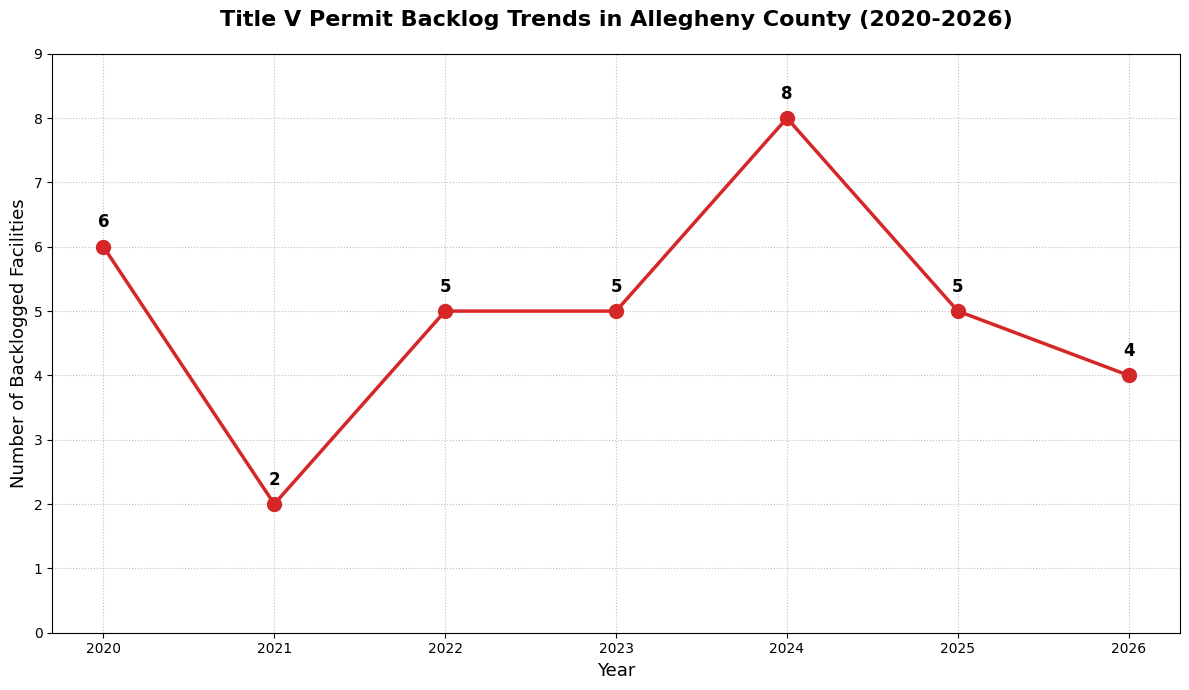

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('ACHD Permit Backlog.csv')

# Aggregate the number of backlogged facilities per year
backlog_counts = df.groupby('Year').size().to_dict()

# Include the 2026 data point
backlog_counts[2026] = 4

# Prepare the plot
sorted_years = sorted(backlog_counts.keys())
counts = [backlog_counts[year] for year in sorted_years]

plt.figure(figsize=(12, 7))
plt.plot(sorted_years, counts, marker='o', linestyle='-', color='#d62728', linewidth=2.5, markersize=10)

# Customizing the chart
plt.title('Title V Permit Backlog Trends in Allegheny County (2020-2026)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Year', fontsize=13)
plt.ylabel('Number of Backlogged Facilities', fontsize=13)
plt.xticks(sorted_years)
plt.yticks(range(0, max(counts) + 2))
plt.grid(True, linestyle=':', alpha=0.8)

# Adding labels
for i, count in enumerate(counts):
    plt.text(sorted_years[i], count + 0.3, str(count), ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('backlog_trend_from_csv.png')

In [4]:
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

# Load the consolidated data
df = pd.read_csv('ACHD Permit Backlog.csv')

# Format detail lists for the chart
def format_summary(group):
    lines = [f"• <b>{r['Facility']}</b> ({r['Location']})<br>  Applied: {r['Renewal App Submitted']} | Expired: {r['Last Permit Expired']}" 
             for _, r in group.iterrows()]
    return "<br><br>".join(lines)

summary = df.groupby('Year').apply(lambda x: pd.Series({
    'Count': len(x),
    'Details': format_summary(x)
})).reset_index()

# Create the Interactive Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=summary['Year'],
    y=summary['Count'],
    mode='lines+markers',
    marker=dict(size=14, color='#2980b9', line=dict(width=2, color='white')),
    line=dict(width=3, color='#3498db'),
    customdata=summary['Details'],
    hovertemplate="<b>Year: %{x}</b><br>Backlog: %{y}<br><br>%{customdata}<extra></extra>"
))

fig.update_layout(
    title='<b> ACHD Permit Backlog Trend (2020-2026)</b>',
    xaxis=dict(title='Year', tickmode='linear'),
    yaxis=dict(title='Backlogged Facility Count', range=[0, 10]),
    template='plotly_white',
    hoverlabel=dict(bgcolor="white", font_size=12, align="left")
)

# In Jupyter, this will display immediately with full interactivity:
fig.show()

/var/folders/lv/3jr7lysd5j1899gbwn00rv480000gn/T/ipykernel_19359/2970030949.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby('Year').apply(lambda x: pd.Series({
